<a href="https://colab.research.google.com/github/SaniyaIrfan1113/Fabric-defect-detection-using-deep-learning/blob/main/yolov5_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Sun Mar  2 07:26:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Install YOLOv5


In [ ]:
# clone YOLOv5 repository
%cd /content
!git clone https://github.com/ultralytics/yolov5

/content
Cloning into 'yolov5'...
remote: Enumerating objects: 17270, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 17270 (delta 0), reused 0 (delta 0), pack-reused 17269 (from 2)
Receiving objects: 100% (17270/17270), 16.12 MiB | 14.95 MiB/s, done.
Resolving deltas: 100% (11858/11858), done.


In [ ]:
# install dependencies as necessary
!pip install -r requirements.txt
!pip uninstall wandb -qy  # deprecated dependency
import torch

from IPython.display import Image, clear_output  # to display images

# clear_output()
print('Setup complete. Using torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Setup complete. Using torch 2.5.1+cu124 _CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=15095MB, multi_processor_count=40, uuid=9f1a9a2a-34e7-6b80-f747-5b37d8b0ff0f, L2_cache_size=4MB)


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="pilo1phCa5MQHOOzhDzc")
project = rf.workspace("saniya-irfan-vtnss").project("my-first-project-7oq45")
version = project.version(1)
dataset = version.download("yolov5")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.1/83.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-1 in yolov5pytorch:: 100%|██████████| 3532/3532 [00:00<00:00, 5694.99it/s]


In [ ]:
# train yolov5s on custom data for 25 epochs
# time its performance
%%time
%cd /content/yolov5/
!python train.py \
  --img 416 \
  --batch 16 \
  --epochs 80 \
  --data {dataset.location}/data.yaml \
  --weights yolov5s.pt \
  --name yolov5s_results  \
  --cache

Streaming output truncated to the last 5000 lines.
      55/79      1.93G     0.0318    0.01078   0.002359         35        416:  20% 20/98 [00:02<00:11,  6.82it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      55/79      1.93G     0.0317     0.0107   0.002287         33        416:  21% 21/98 [00:03<00:11,  6.69it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      55/79      1.93G    0.03159    0.01066   0.002294         30        416:  22% 22/98 [00:03<00:11,  6.46it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      55/79      1.93G    0.03189    

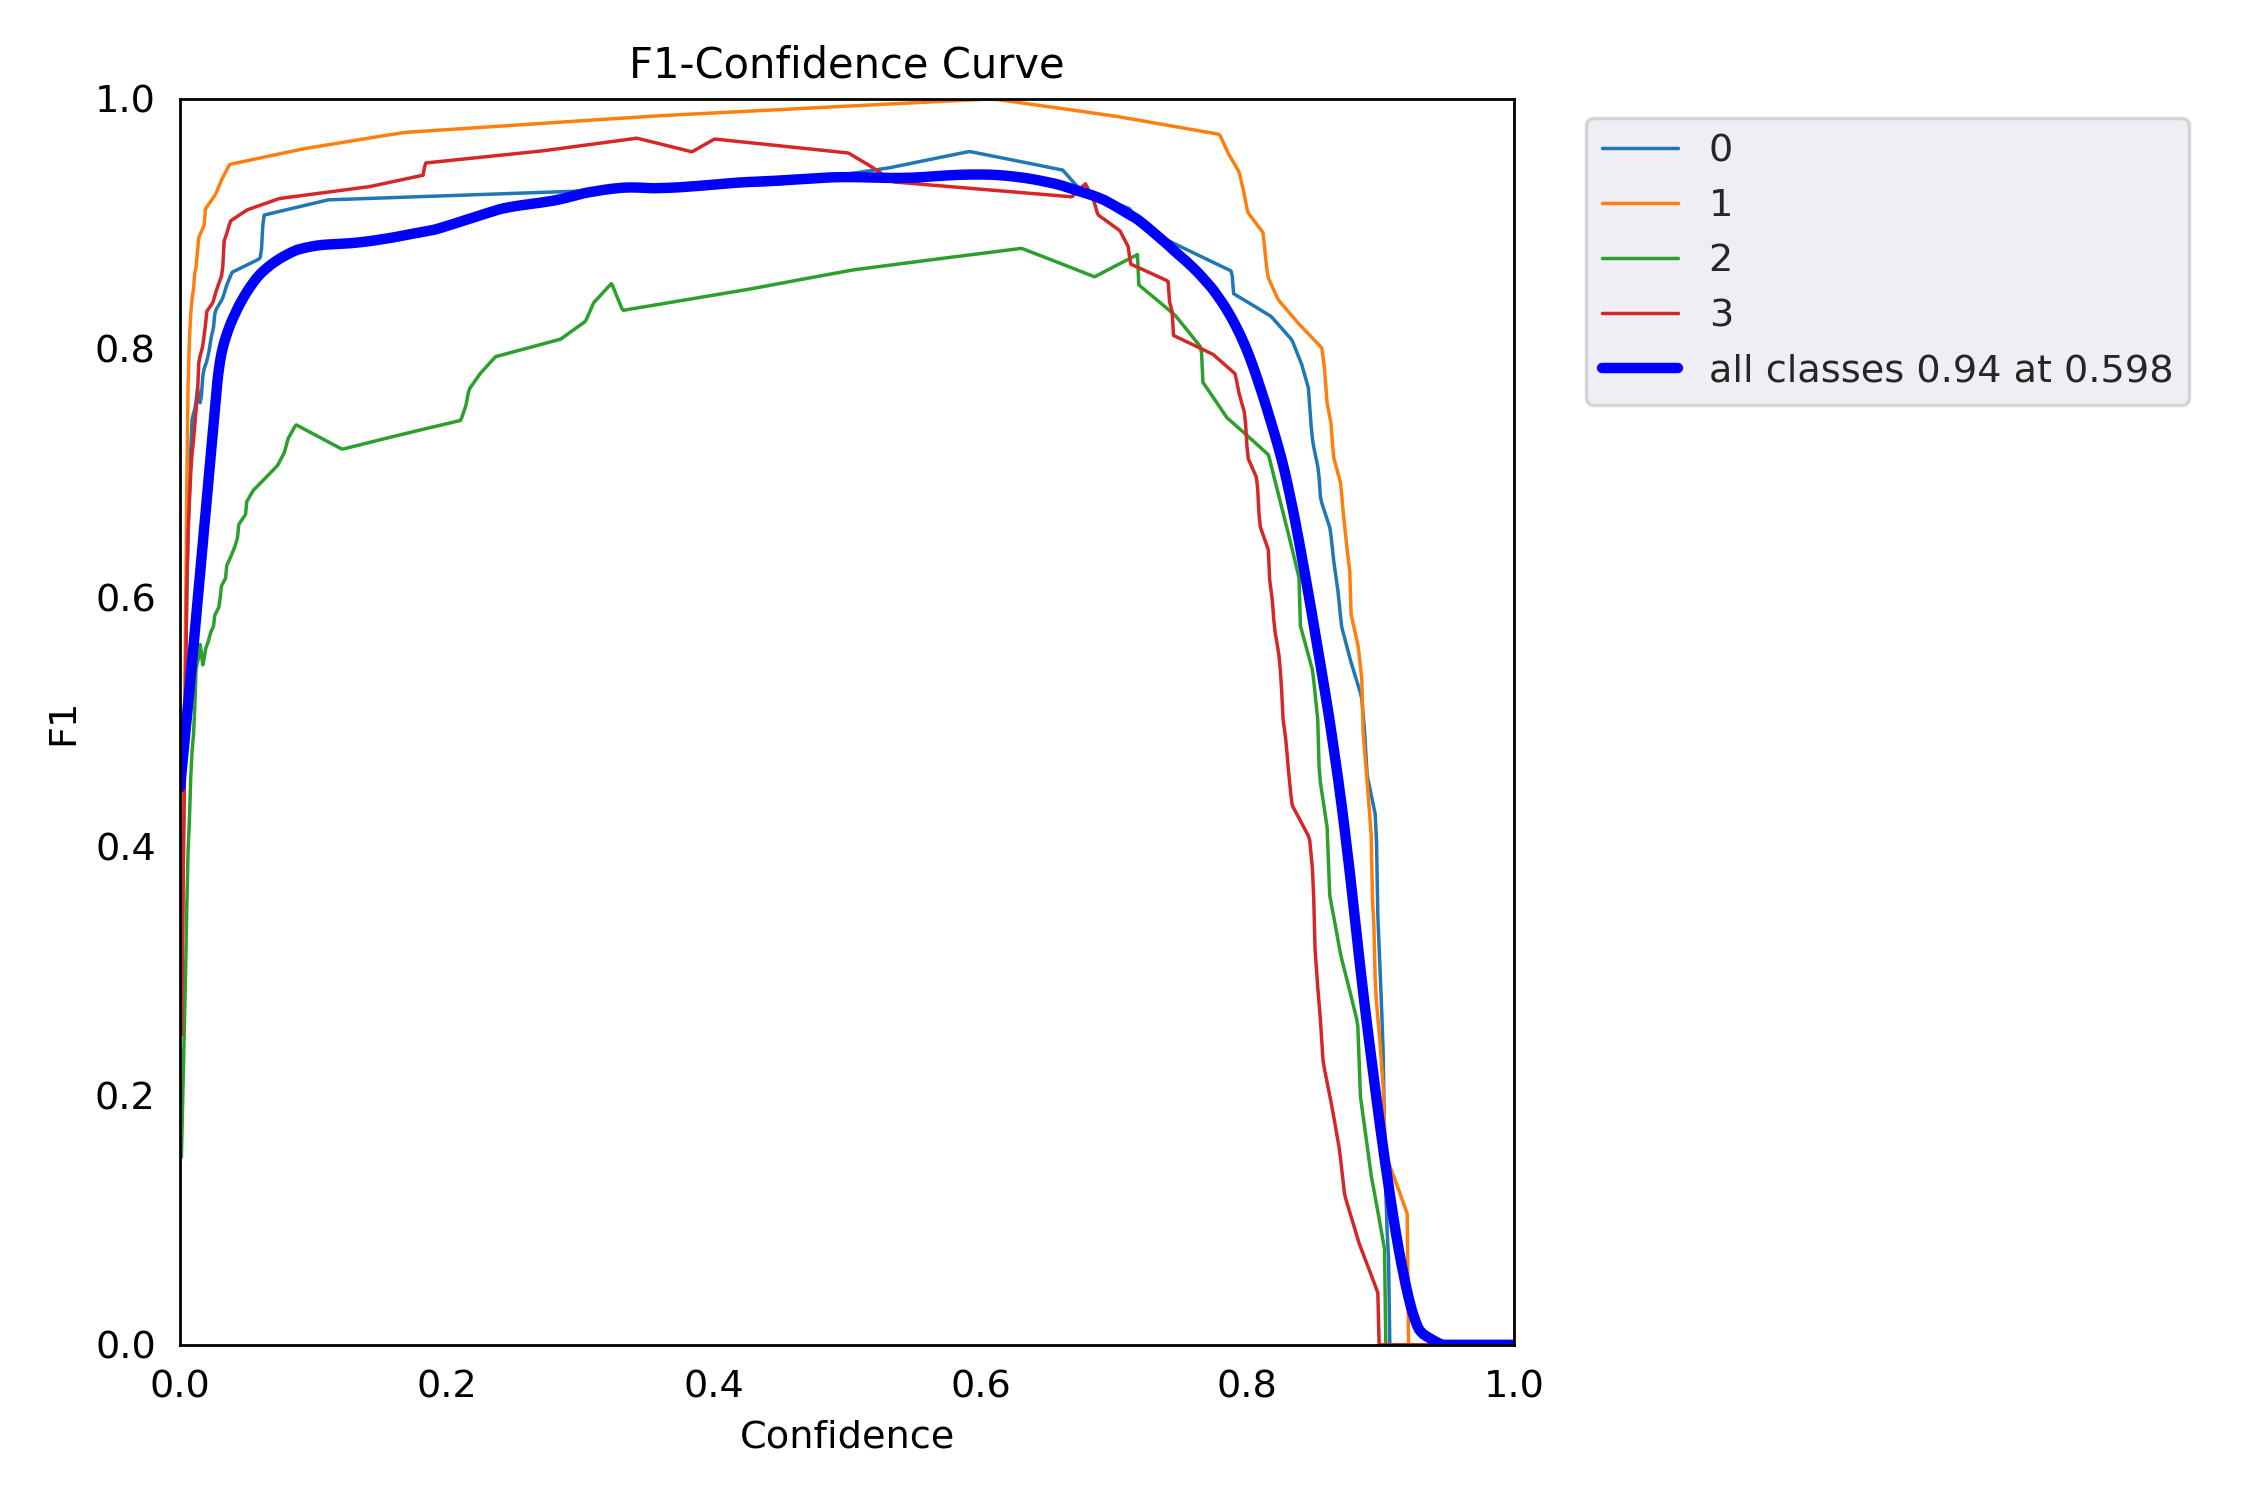

In [ ]:
from utils.plots import plot_results  # plot results.txt as results.png
Image(filename='/content/yolov5/runs/train/yolov5s_results3/F1_curve.png', width=1000)

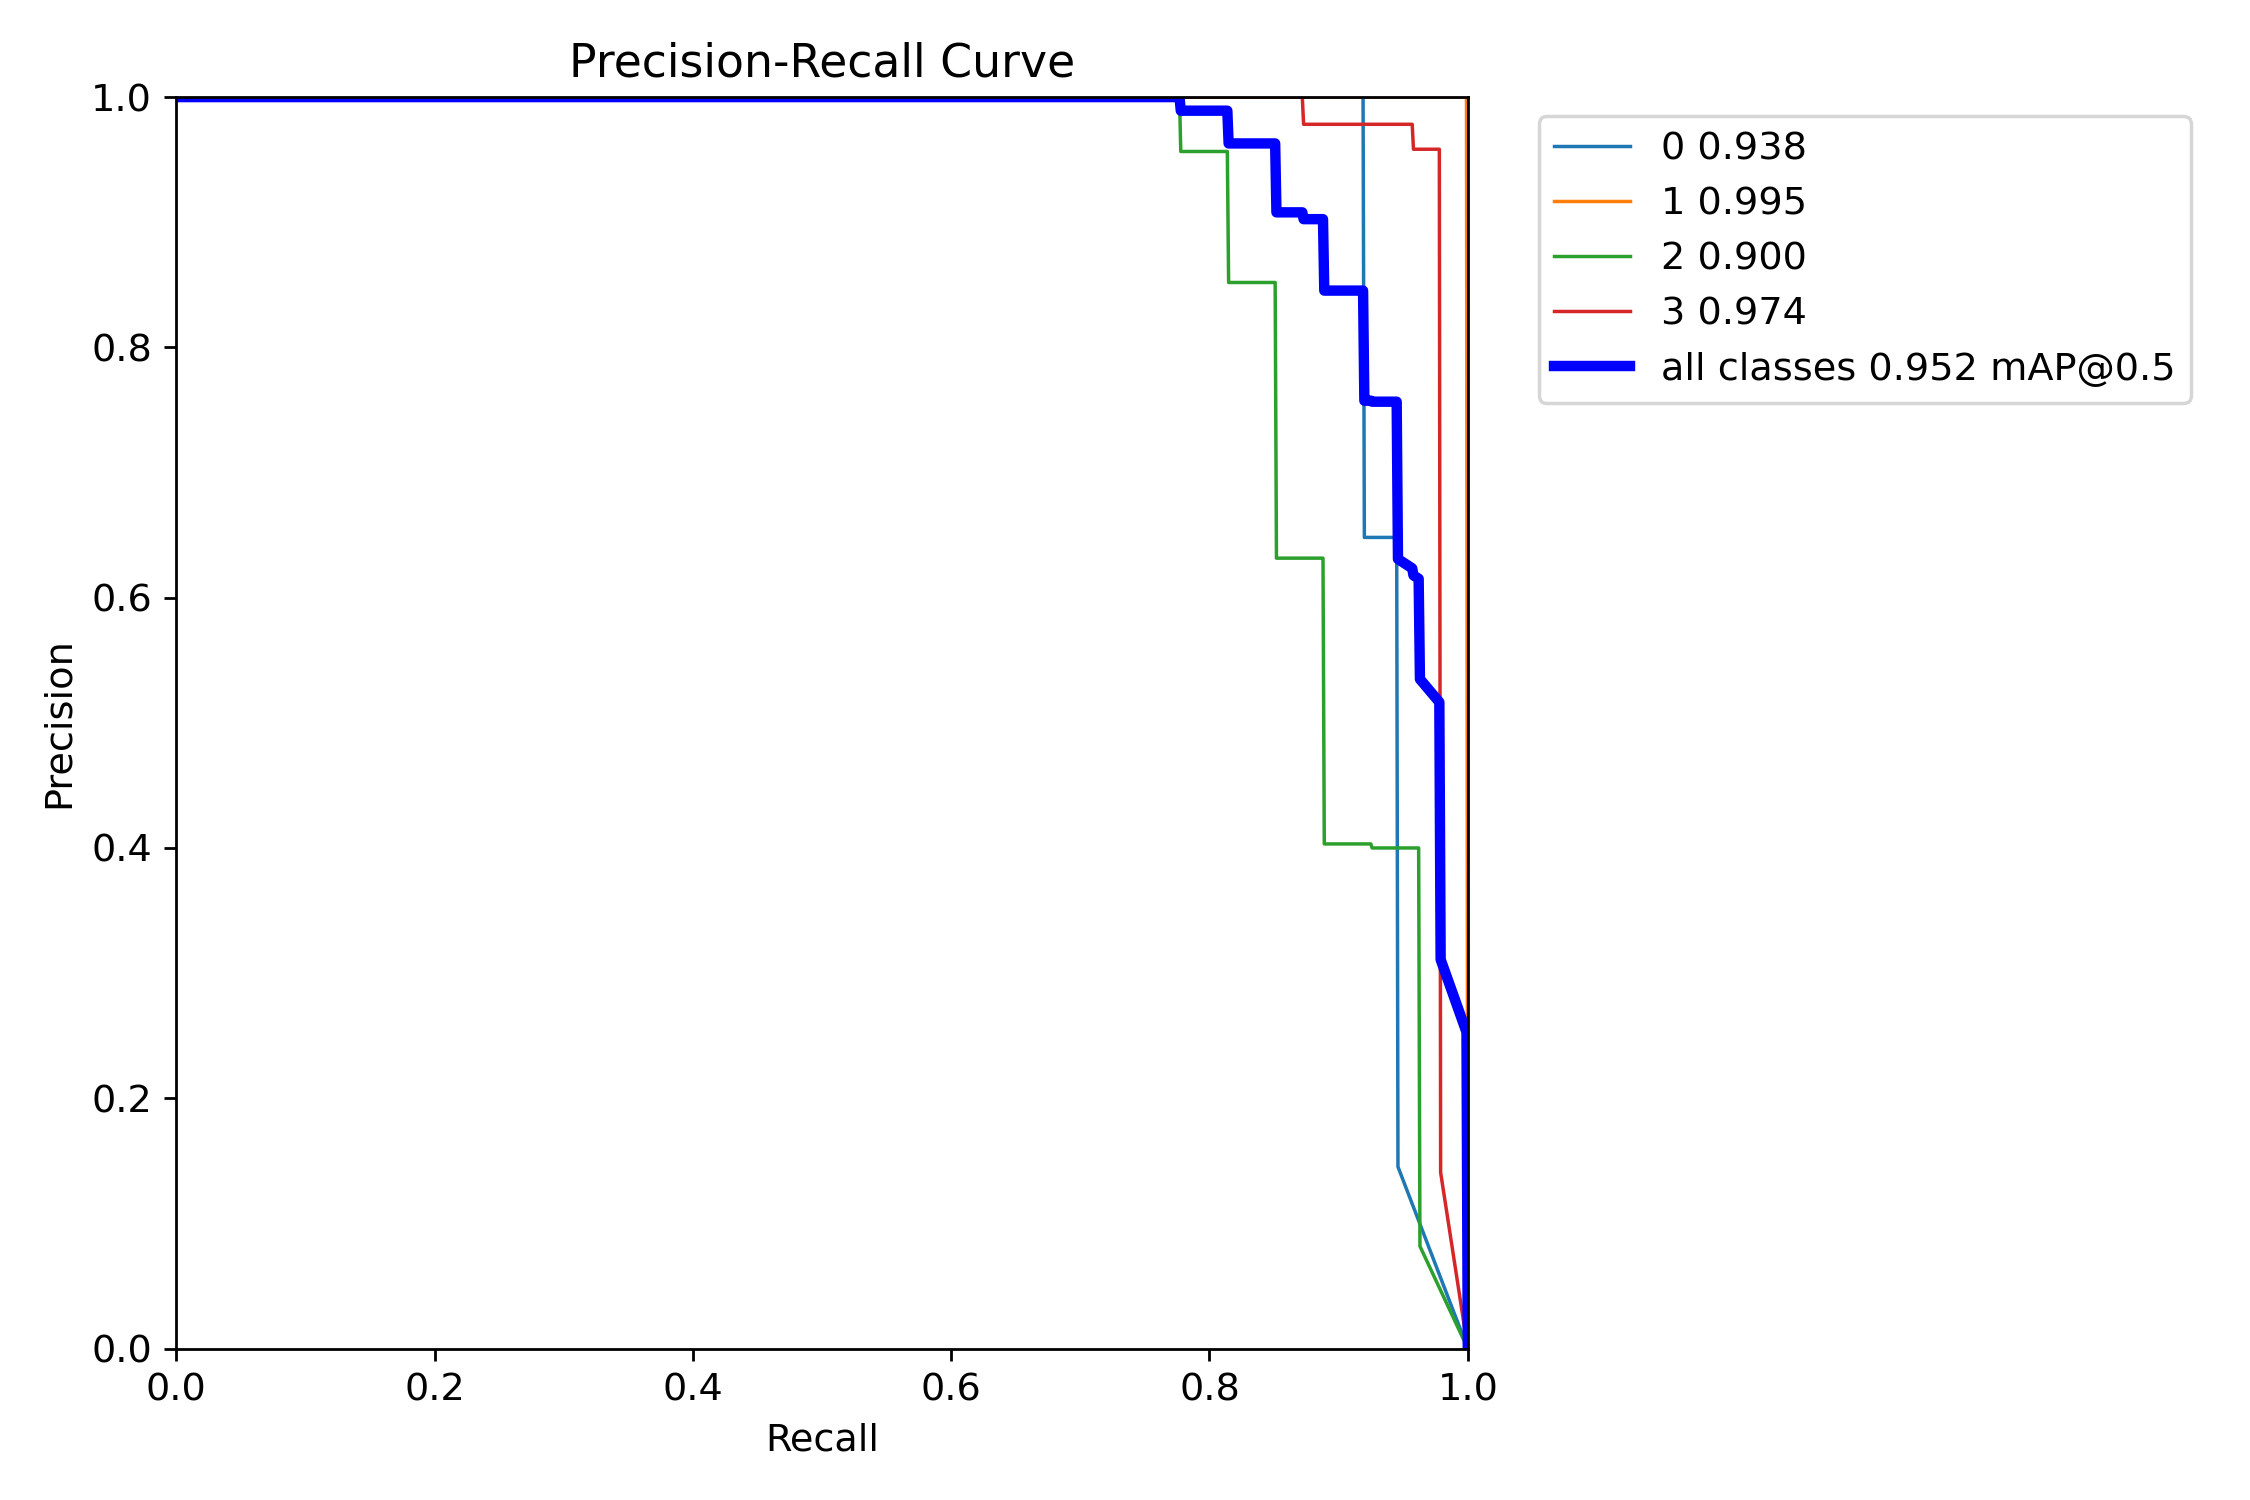

In [ ]:
from utils.plots import plot_results  # plot results.txt as results.png
Image(filename='/content/yolov5/runs/train/yolov5s_results3/PR_curve.png', width=1000)

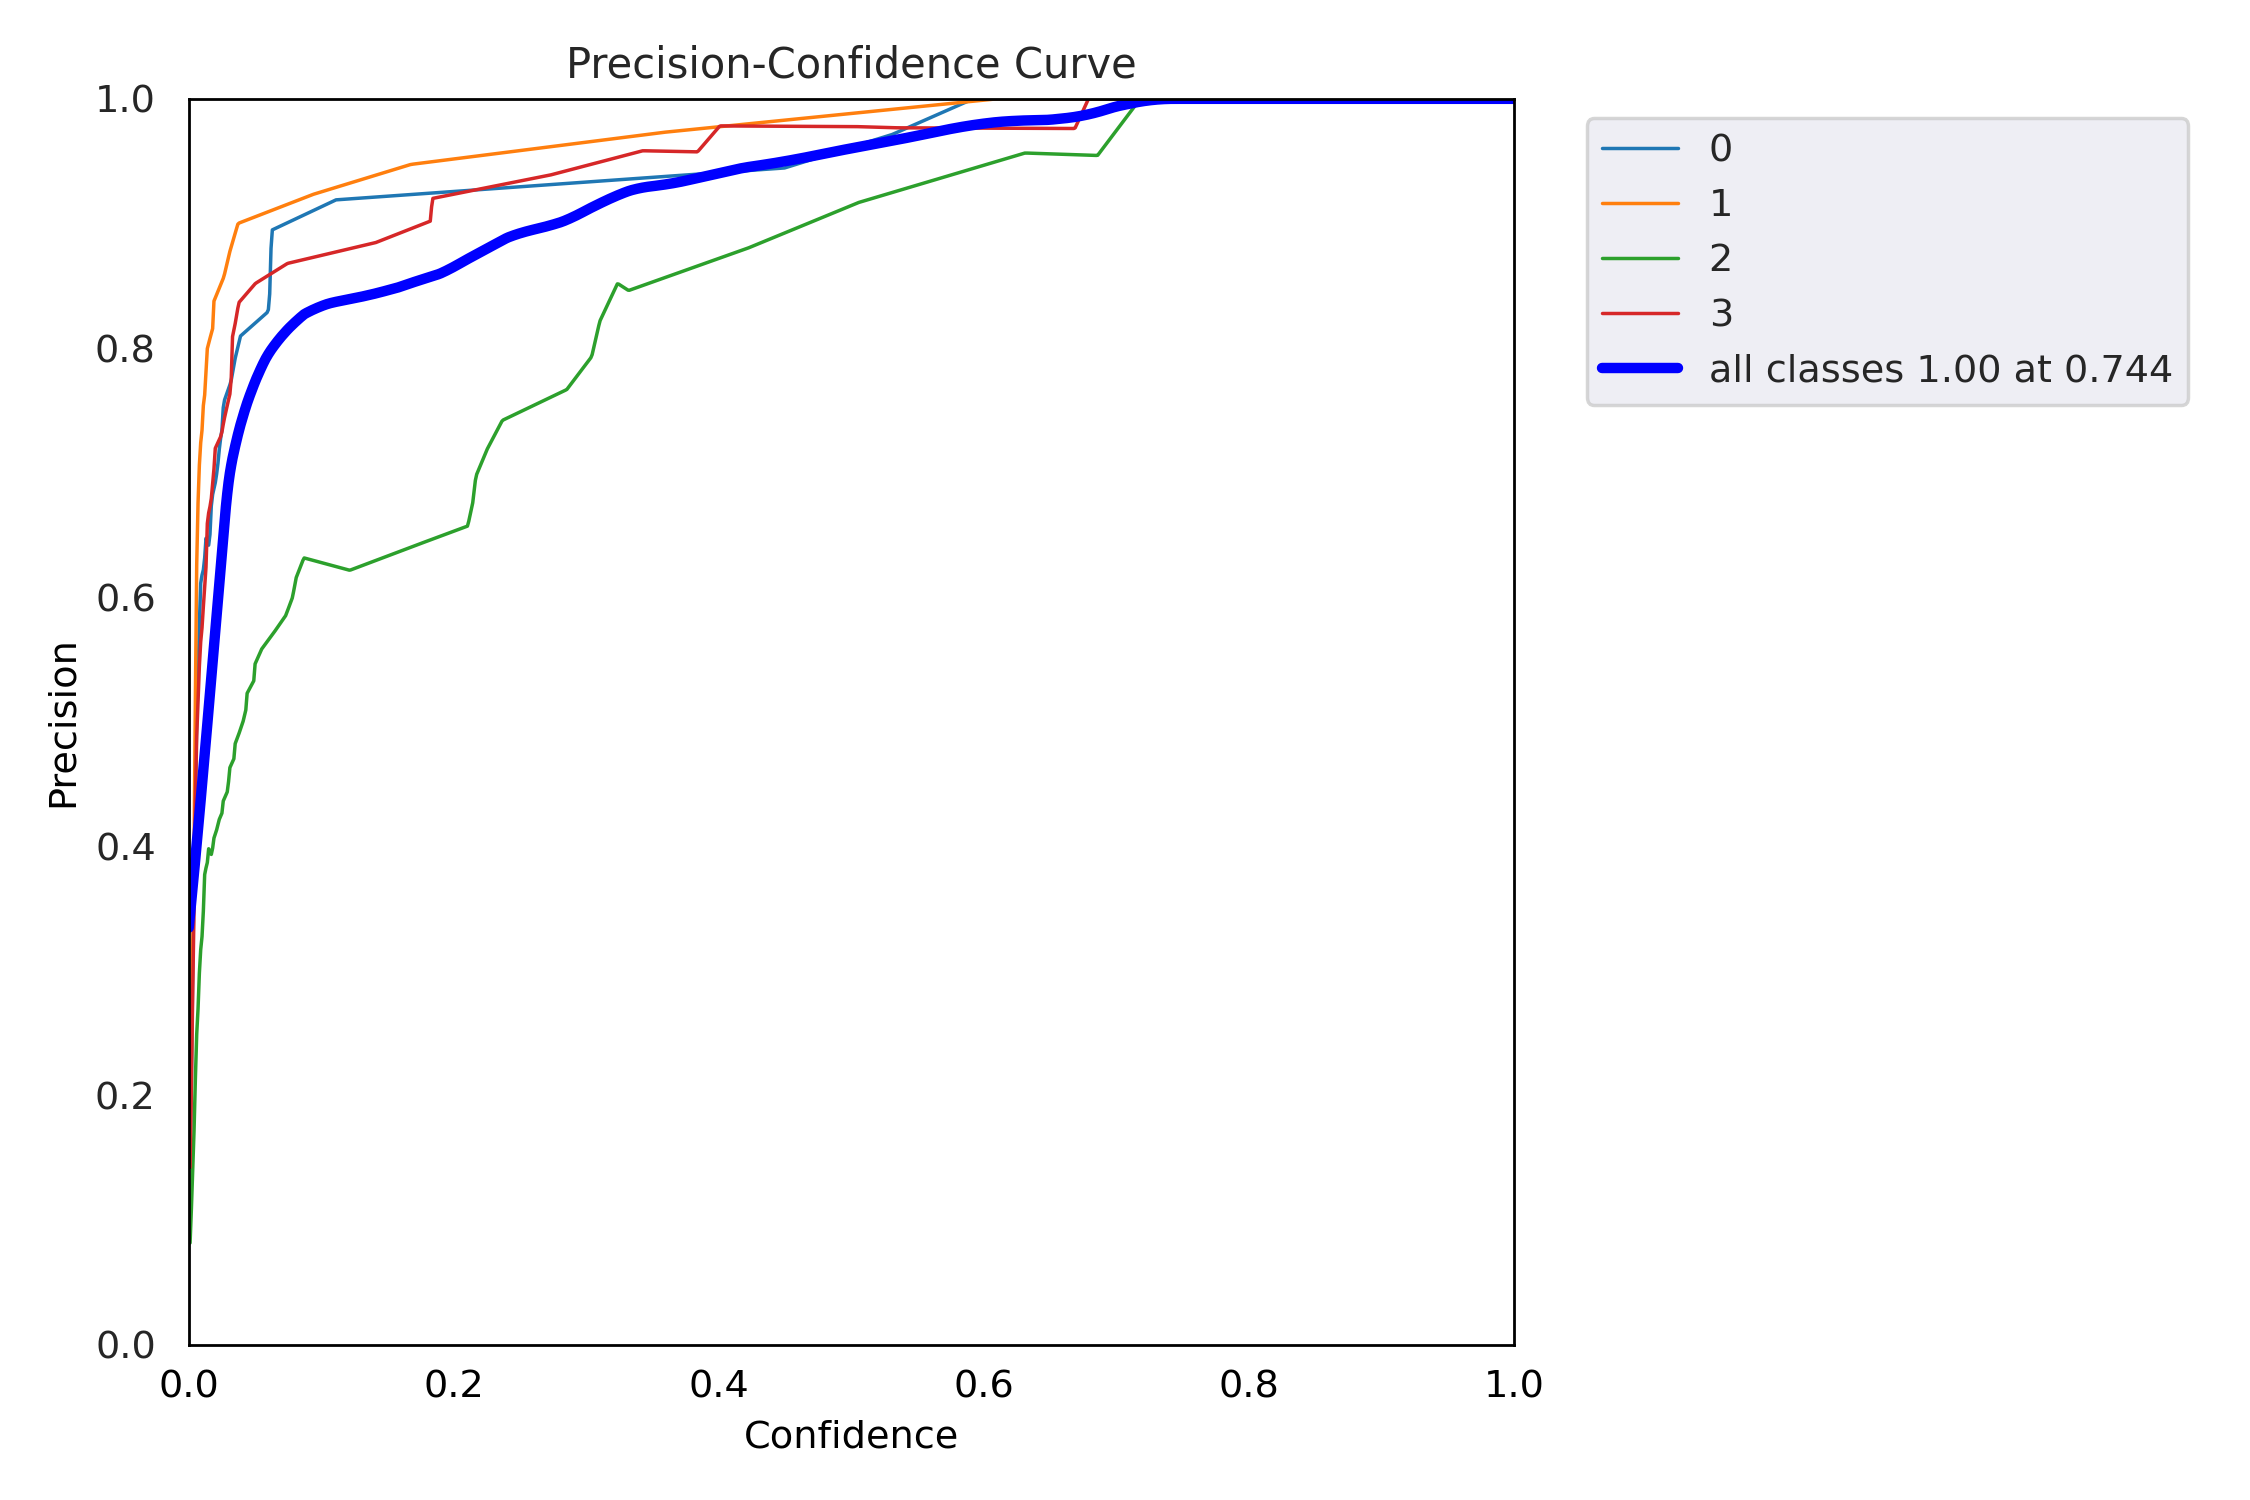

In [ ]:
from utils.plots import plot_results  # plot results.txt as results.png
Image(filename='/content/yolov5/runs/train/yolov5s_results3/P_curve.png', width=1000)

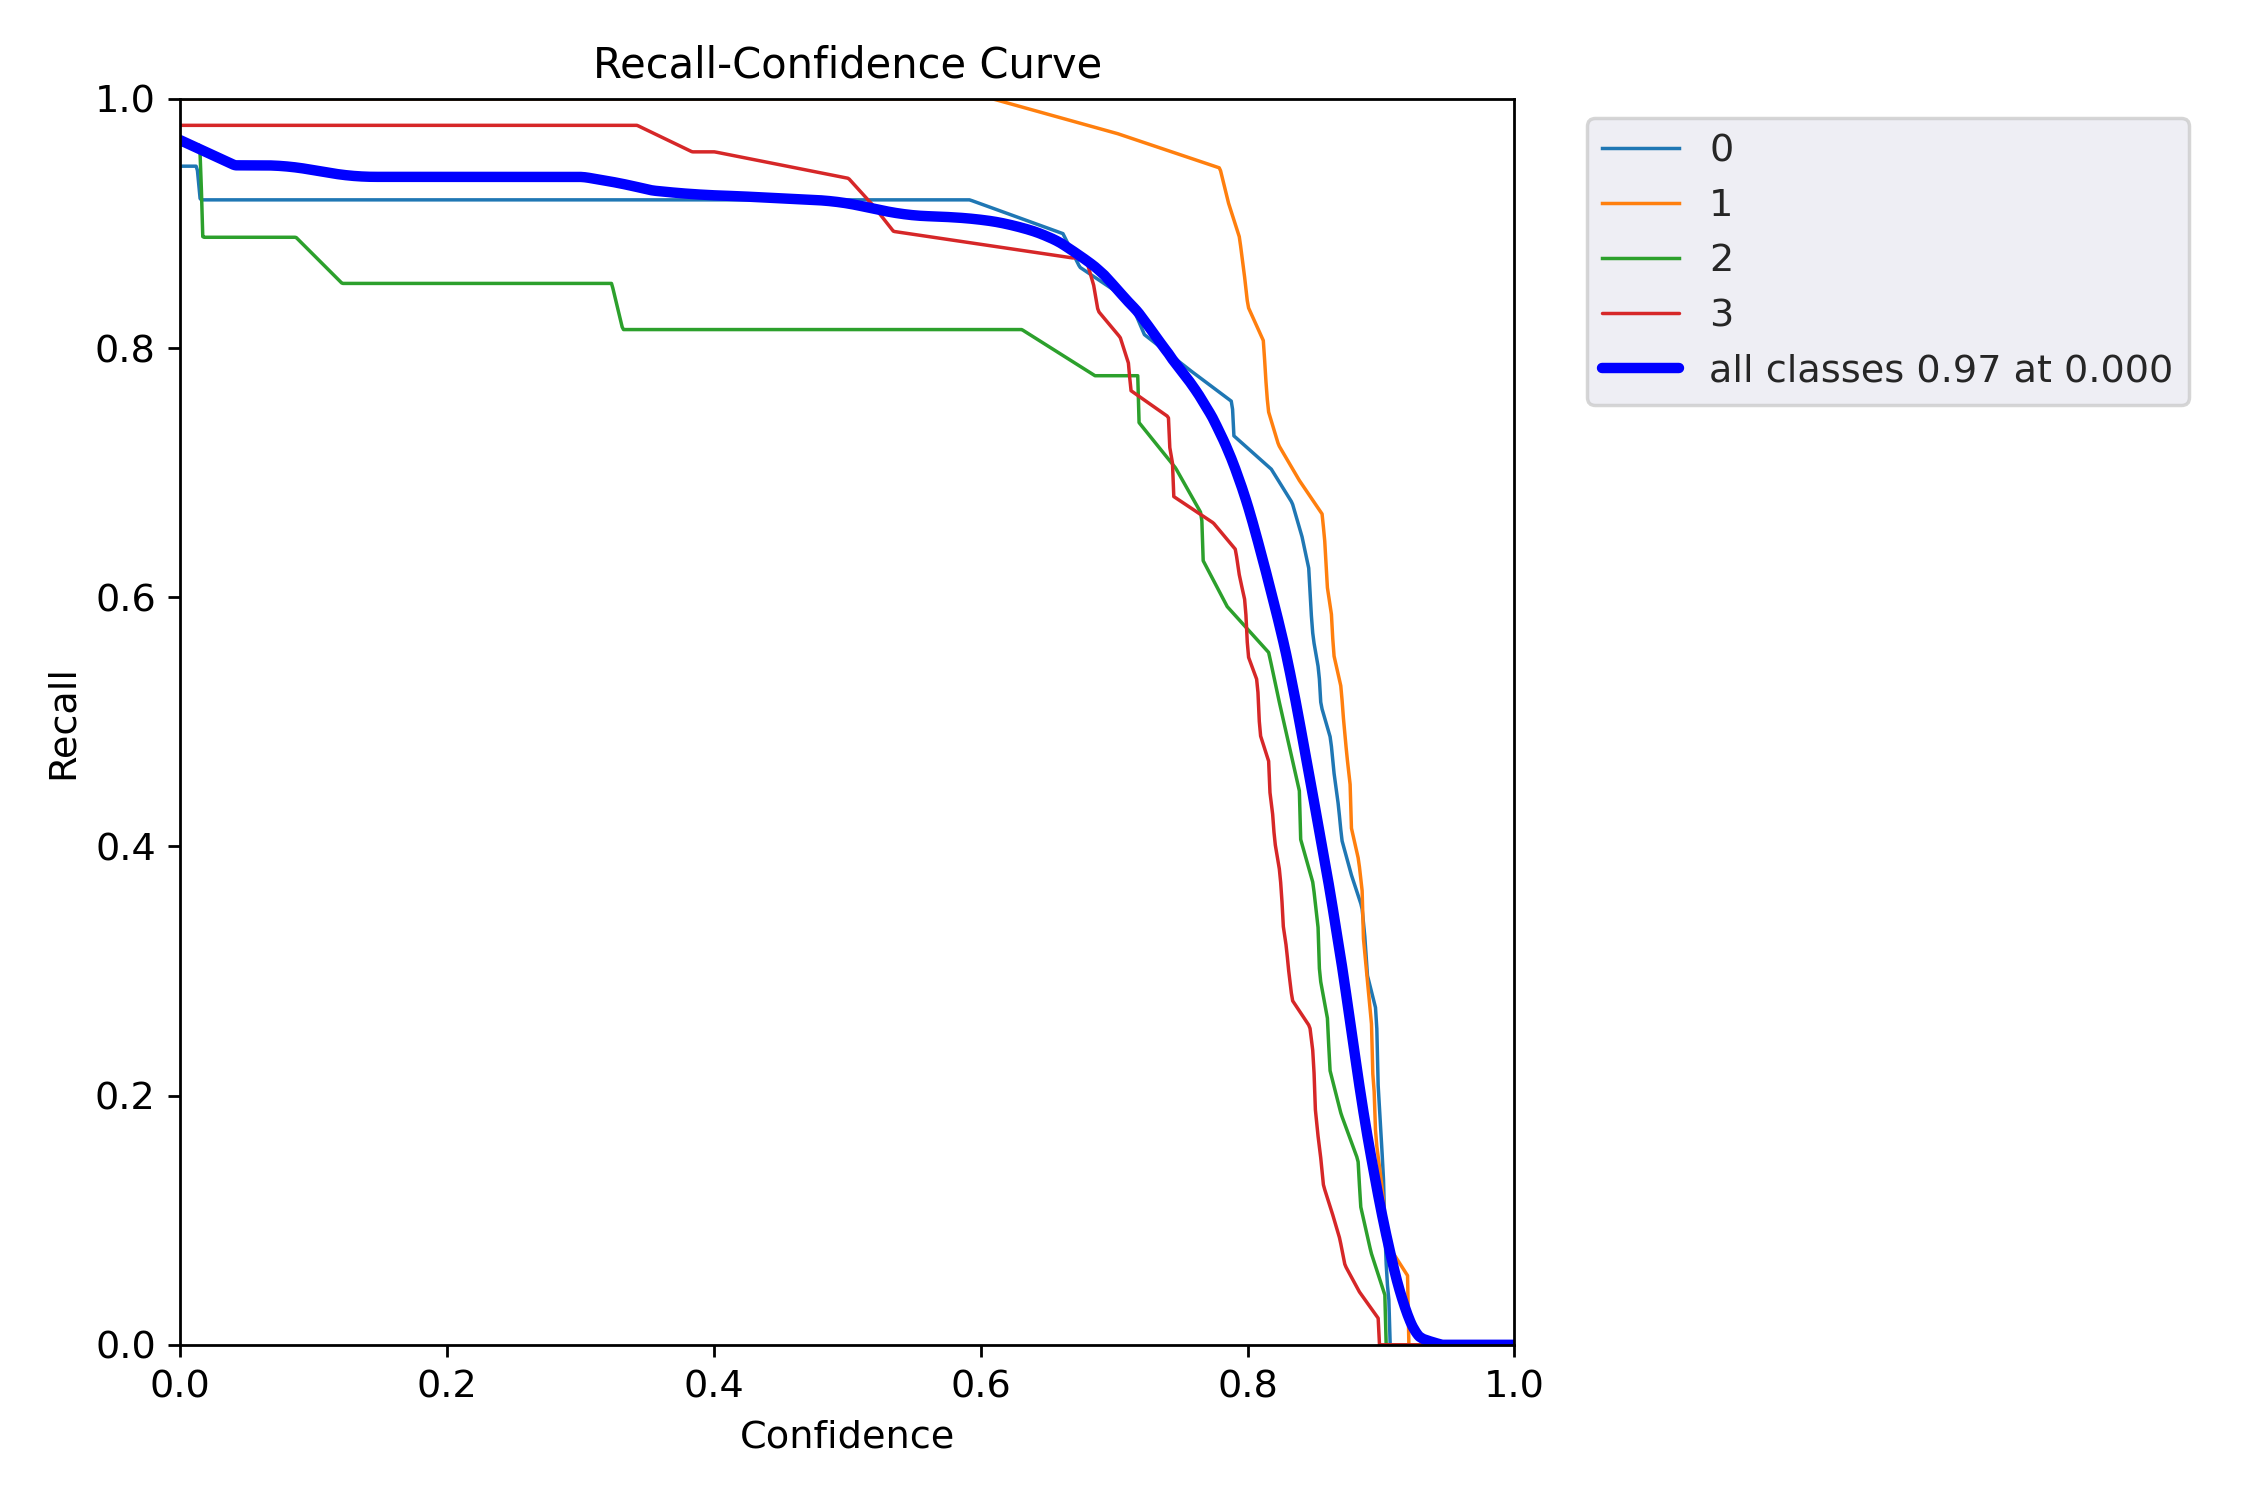

In [ ]:
from utils.plots import plot_results  # plot results.txt as results.png
Image(filename='/content/yolov5/runs/train/yolov5s_results3/R_curve.png', width=1000)

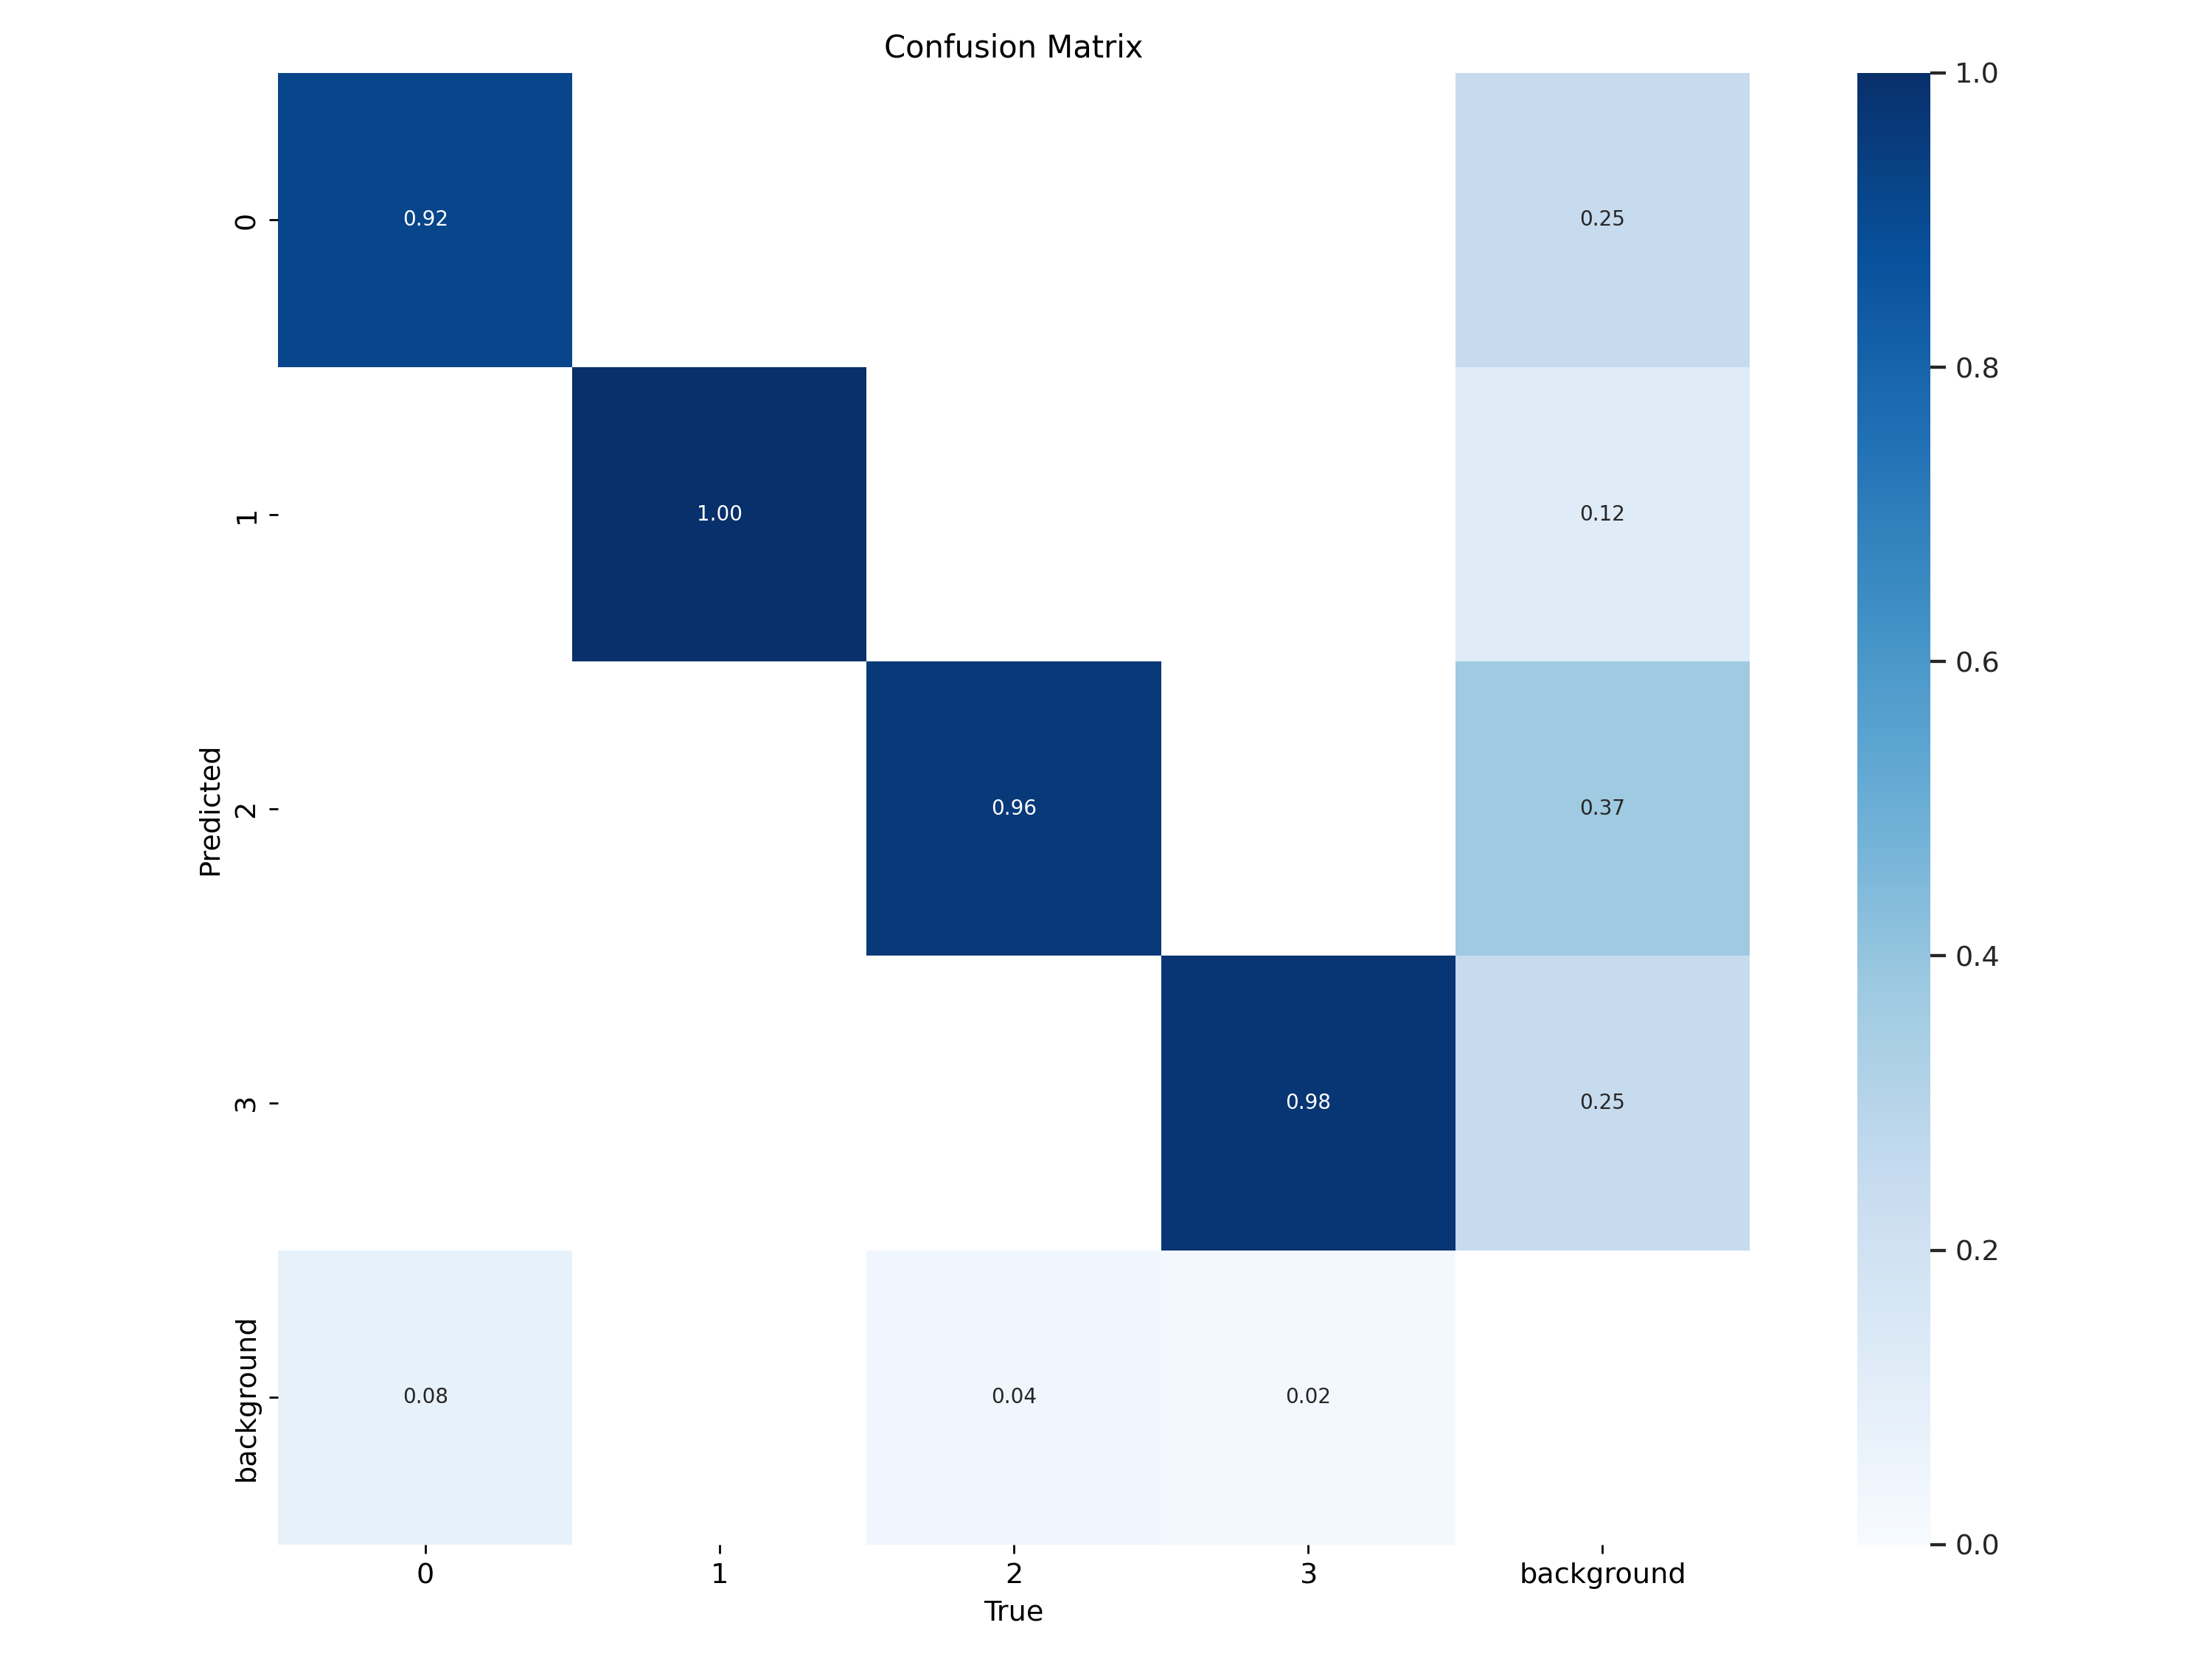

In [ ]:
Image(filename='/content/yolov5/runs/train/yolov5s_results3/confusion_matrix.png', width=900)

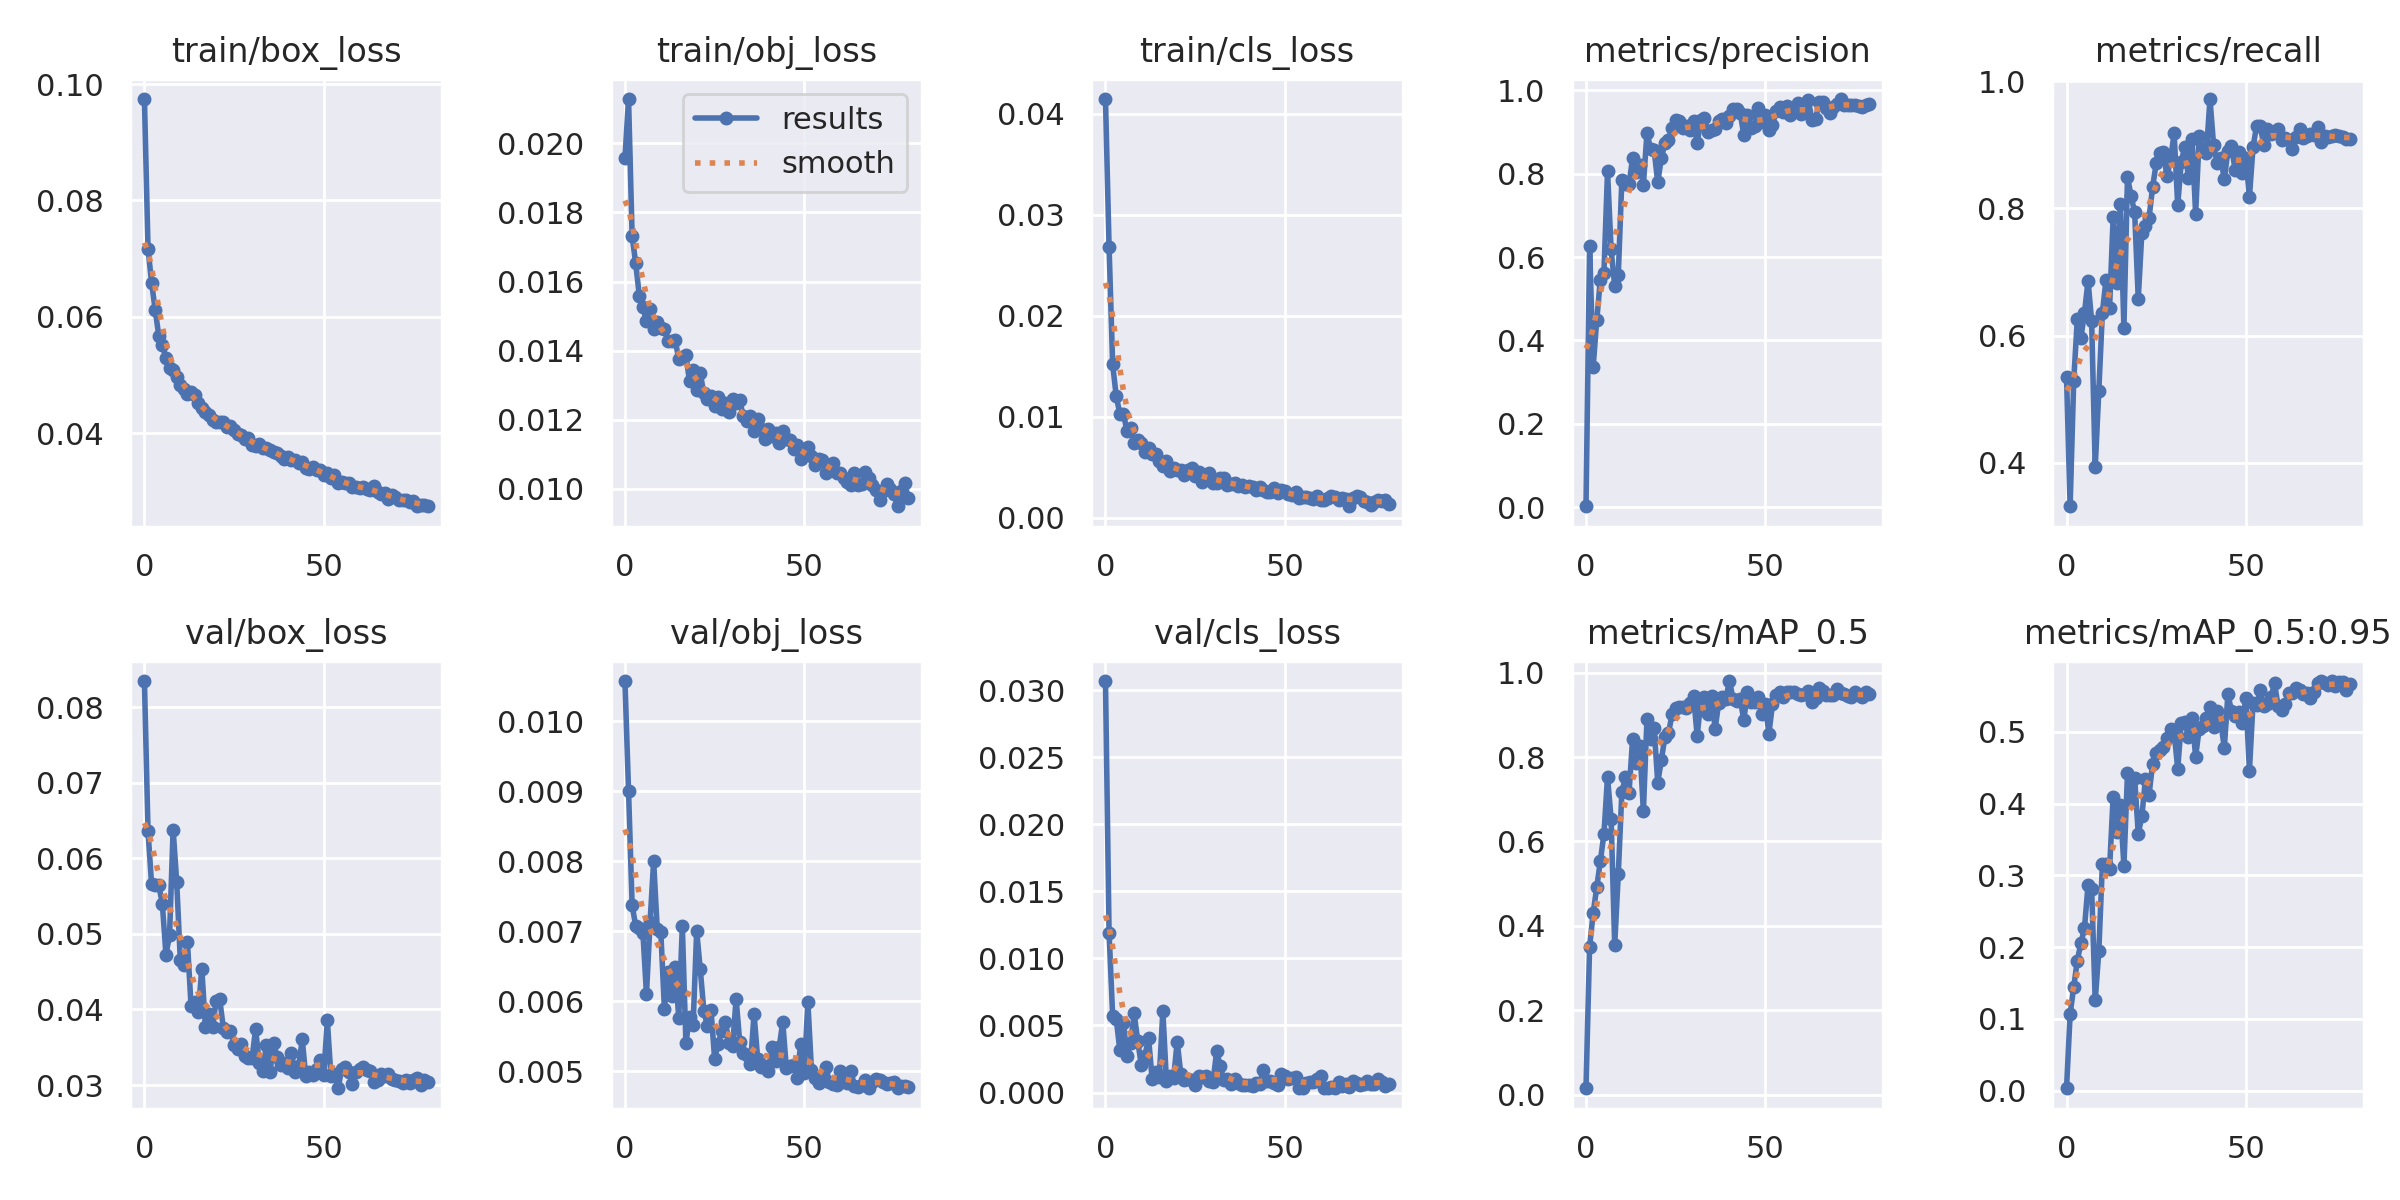

In [ ]:
Image(filename='/content/yolov5/runs/train/yolov5s_results3/results.png', width=900)

GROUND TRUTH AUGMENTED TRAINING DATA:


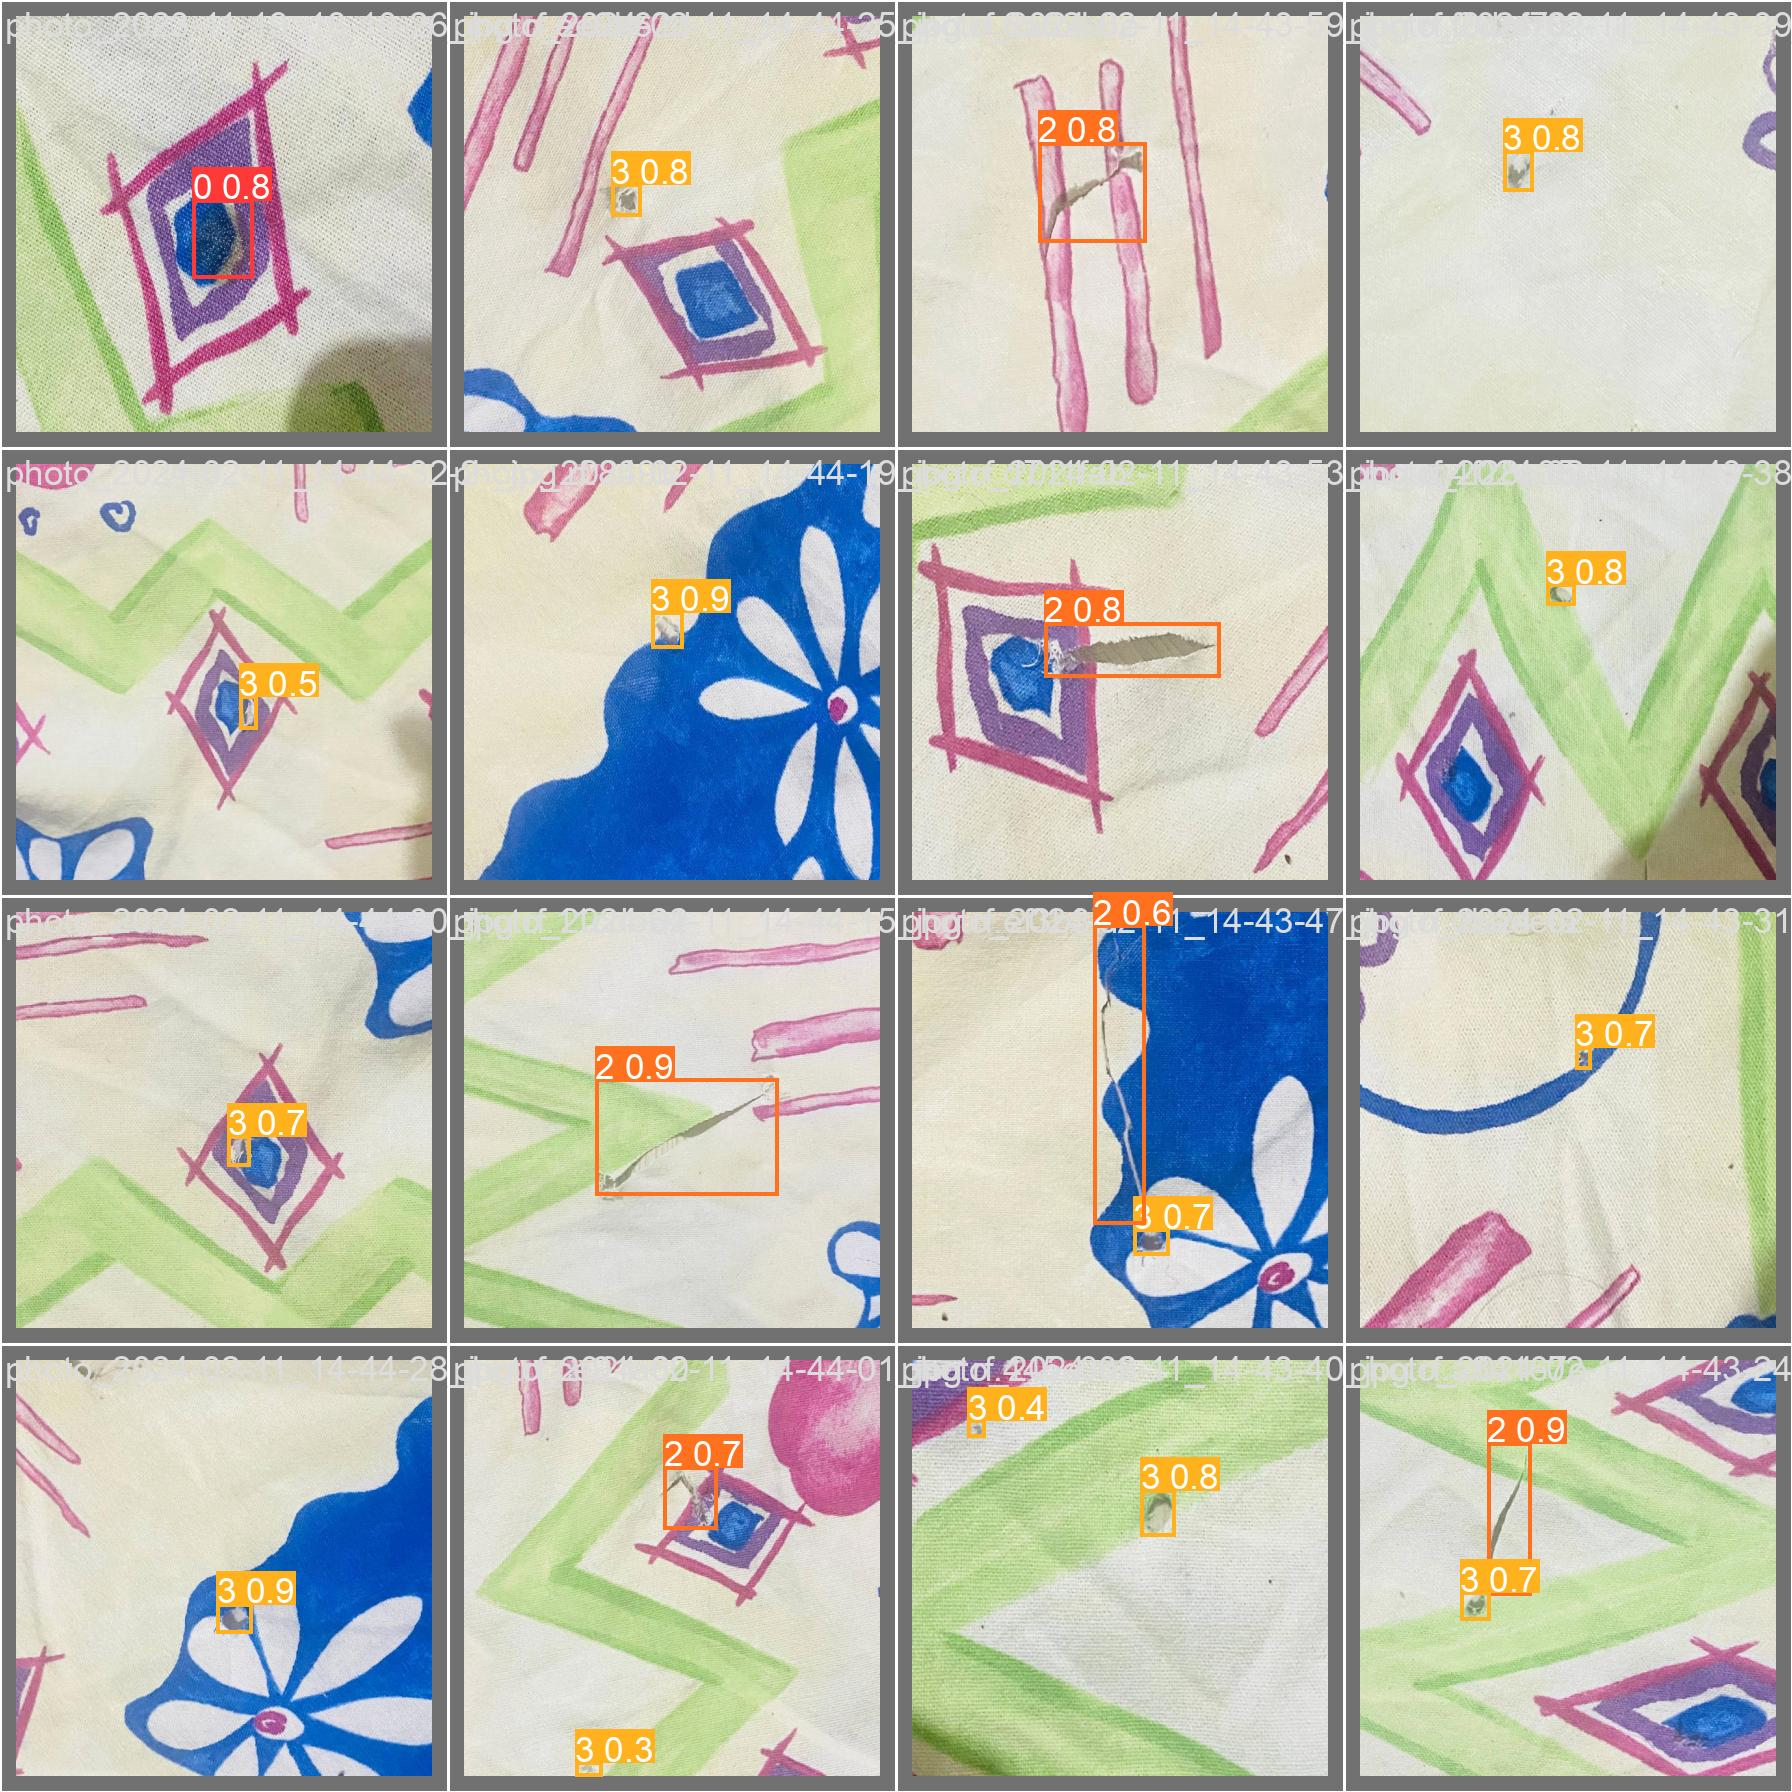

In [ ]:
# print out an augmented training example
print("GROUND TRUTH AUGMENTED TRAINING DATA:")
Image(filename='/content/yolov5/runs/train/yolov5s_results3/val_batch0_pred.jpg', width=900)

In [ ]:
import re

# Sample YOLO output
yolo_output = """
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 5/5 [00:02<00:00,  2.19it/s]
                   all        133        147      0.979      0.905      0.952      0.572
"""

# Extract mAP@50 using regex
match = re.search(r"all\s+\d+\s+\d+\s+[\d.]+\s+[\d.]+\s+([\d.]+)", yolo_output)
if match:
    accuracy = float(match.group(1)) * 100
    print(f"🎯 Model Accuracy: {accuracy:.1f}%")
else:
    print("⚠️ Accuracy not found.")


🎯 Model Accuracy: 95.2%
